# Lorenz (1996) — Single-scale and Two-scale Atmospheric Models

An N-variable chaotic system on a periodic ring, with an optional fast-variable layer that introduces two-timescale dynamics.

## Overview

The Lorenz (1996) system was introduced as a testbed for data assimilation algorithms: simple enough to integrate cheaply over thousands of ensemble members, yet chaotic enough to make prediction non-trivial. The single-scale variant (`Lorenz96` with `J=0`, the default) is a periodic ring of *n* variables with local quadratic advection and constant forcing. Passing `J > 0` activates a second, faster layer of *n × J* variables, giving the two-scale system of Lorenz & Emanuel (1998). The slow-variable equations are identical in both cases — the coupling term simply vanishes at `J=0`.

## Literature

- Lorenz, E. N. (1996). Predictability: A problem partly solved. In *Proc. ECMWF Seminar on Predictability*, Vol. 1, pp. 1–18. ECMWF, Reading, UK.
- Lorenz, E. N., & Emanuel, K. A. (1998). Optimal sites for supplementary weather observations: simulation with a small model. *Journal of the Atmospheric Sciences*, 55(3), 399–414. https://doi.org/10.1175/1520-0469(1998)055<0399:OSFSWO>2.0.CO;2

**Figures reproduced below:**
- Figure 1 equivalent: single-scale space-time diagram (Lorenz 1996 Fig. 1)
- Figure 2 equivalent: two-scale X and Y dynamics showing timescale separation (Lorenz & Emanuel 1998)


## Equations

**Single-scale** ($n$ variables, all on the same timescale):

$$
\frac{dX_i}{dt} = (X_{i+1} - X_{i-2})\,X_{i-1} - X_i + F, \qquad i = 0,\ldots,n-1
$$

Indices are cyclic mod $n$.

**Two-scale** ($K$ slow variables $X$, each coupled to $J$ fast variables $Y$):

$$
\frac{dX_k}{dt} = (X_{k+1} - X_{k-2})\,X_{k-1} - X_k + F - \frac{hc}{b}\sum_{j=0}^{J-1} Y_{k,j}
$$

$$
\frac{dY_{k,j}}{dt} = -cb\,Y_{k,j+1}(Y_{k,j+2} - Y_{k,j-1}) - c\,Y_{k,j} + \frac{hc}{b}\,X_k
$$

The X equation is identical to the single-scale equation plus the coupling term $-\frac{hc}{b}\sum_j Y_{k,j}$, which vanishes when $J=0$. Y indices are cyclic within each $k$-block.

## Parameters

| Symbol | `param_values` key | Default | Meaning |
|--------|-------------------|---------|--------|
| $n$ | — | 40 | Number of slow-scale variables |
| $J$ | — | 0 | Fast variables per slow variable; `J=0` gives the single-scale system |
| $F$ | `F` | 8.0 | External forcing; $F \geq 5/6$ puts the single-scale system in the chaotic regime |
| $h$ | `h` | 1.0 | Coupling coefficient between X and Y (two-scale only) |
| $b$ | `b` | 10.0 | Amplitude ratio $Y/X$ (two-scale only) |
| $c$ | `c` | 10.0 | Timescale ratio $Y/X$; Y evolves $c$ times faster than X (two-scale only) |

## State variables

| Name | Integrated | Description |
|------|-----------|-------------|
| `x0` … `x{n-1}` | Yes | Slow-scale ring variables |
| `y0` … `y{nJ-1}` | Yes | Fast-scale variables (`J>0` only); `y{k*J + j}` belongs to `x{k}` |

## Implementation notes

When `J > 0`, use `method='l96_rk4'` with `kwargs={'dt': dt, 'si': si}`. The `l96_rk4` path runs a fixed-step RK4 at the Y timescale and samples output at the coarser interval `si`. Adaptive solvers (`RK45`) call `dydt` at sub-steps that corrupt `state_variables` (see the solver section below). Plain Euler at a step coarse enough to resolve only X misses the Y dynamics entirely.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import paleobeasts as pb

## Setup

**Single-scale:** canonical $n=40$, $F=8$ from Lorenz (1996). Random initial conditions on $[-1, 1]$ with fixed seed; the system reaches its attractor within a few time units.

**Two-scale:** canonical $K=36$, $J=10$, $F=10$, $h=b=c=1/10/10$ from Lorenz & Emanuel (1998). The warmup run (10 time units) discards the transient before the production run.

In [3]:
rng = np.random.default_rng(42)

# ── Single-scale ──────────────────────────────────────────────────────────────
n, F_s = 40, 8.0
model_s = pb.Lorenz96(n=n, F=F_s)
model_s.integrate(t_span=(0, 30), y0=rng.uniform(-1, 1, n), method='RK45')
t_eval_s = pb.utils.define_t_eval((0, 30), delta_t=0.05)
state_s = model_s.reframe_time_axis(t_eval_s)

# ── Two-scale ─────────────────────────────────────────────────────────────────
K, J, F_2, h, b, c = 36, 10, 10.0, 1.0, 10.0, 10.0
y0_2 = rng.standard_normal(K + K * J)

# Warmup
model_warm = pb.Lorenz96(n=K, J=J, F=F_2, h=h, b=b, c=c)
model_warm.integrate(t_span=(0, 10), y0=y0_2,
                     method='l96_rk4', kwargs={'dt': 0.001, 'si': 0.05})
y0_warm = np.concatenate(
    [model_warm.state_variables[f'x{k}'][-1:] for k in range(K)] +
    [model_warm.state_variables[f'y{j}'][-1:] for j in range(K * J)]
)

# Production run (fine si to resolve Y dynamics)
model_2 = pb.Lorenz96(n=K, J=J, F=F_2, h=h, b=b, c=c)
model_2.integrate(t_span=(0, 20), y0=y0_warm,
                  method='l96_rk4', kwargs={'dt': 0.001, 'si': 0.005})


## Reproducing Lorenz (1996) Figure 1: single-scale space-time diagram

Lorenz's Figure 1 shows the $n=40$, $F=8$ solution as a space-time diagram: the horizontal axis is variable index (latitude surrogate), the vertical axis is time, and colour encodes $X_i$. Westward-propagating waves emerge from the chaotic dynamics, visible as diagonal bands. This is the canonical reference image for the single-scale system.

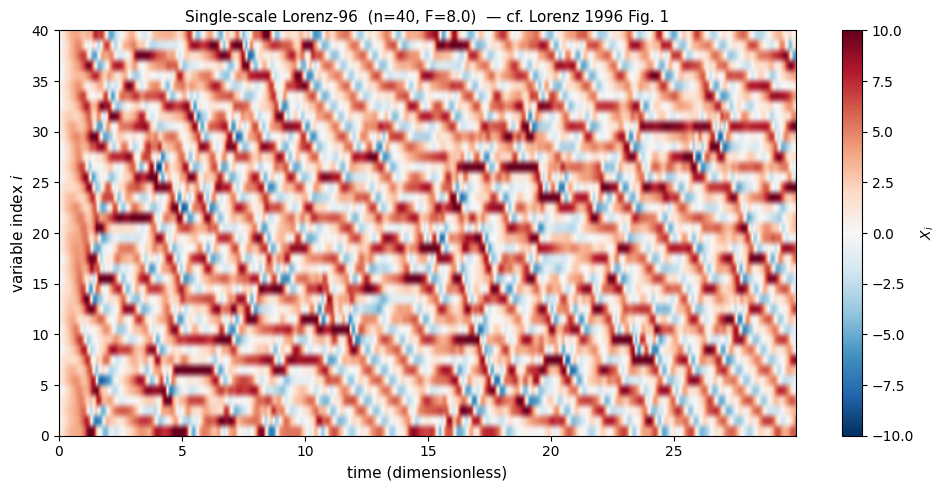

In [4]:
X_mat_s = np.column_stack([state_s[f'x{i}'] for i in range(n)])
t_s = model_s.time

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(
    X_mat_s.T,
    aspect='auto',
    origin='lower',
    extent=[t_s[0], t_s[-1], 0, n],
    cmap='RdBu_r',
    vmin=-10, vmax=10,
)
plt.colorbar(im, ax=ax, label='$X_i$')
ax.set_xlabel('time (dimensionless)', fontsize=11)
ax.set_ylabel('variable index $i$', fontsize=11)
ax.set_title(f'Single-scale Lorenz-96  (n={n}, F={F_s})  — cf. Lorenz 1996 Fig. 1', fontsize=11)
plt.tight_layout()
plt.show()

## Reproducing Lorenz & Emanuel (1998): two-scale X and Y dynamics

With $c=10$ the Y variables evolve ten times faster than X. The top panel shows the slow oscillation of a single X variable; the bottom panel shows the $J=10$ fast Y variables coupled to it, riding on top of the slow X signal. The timescale separation is immediately visible. This captures the phenomenology demonstrated throughout Lorenz & Emanuel (1998).

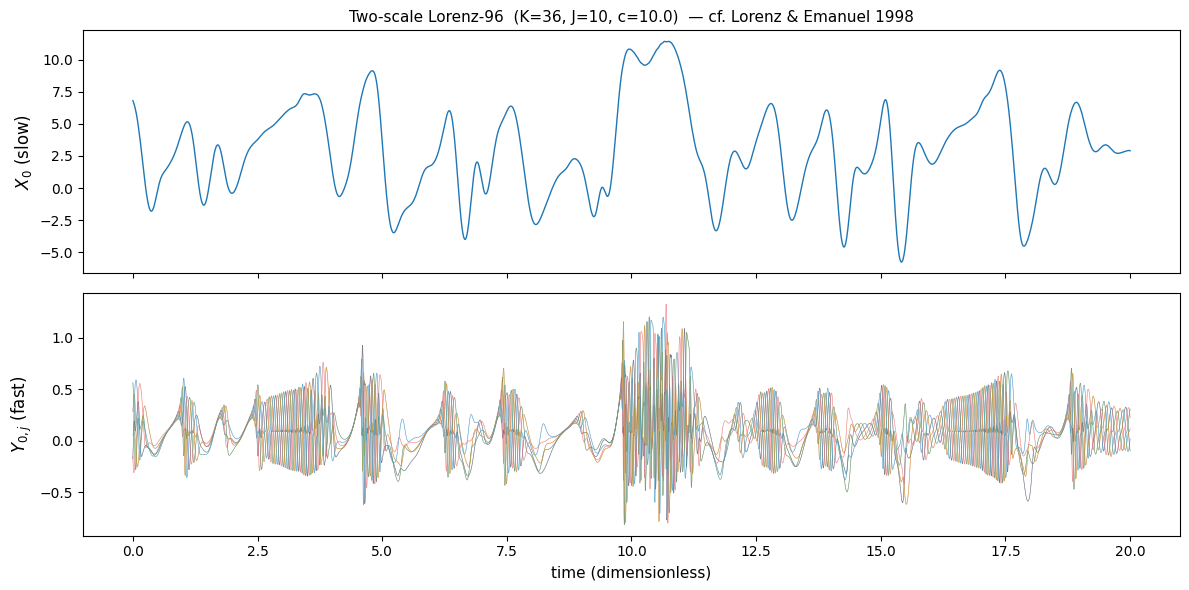

In [5]:
t_2 = model_2.time
x0_ts = model_2.state_variables['x0']
# Y variables belonging to X[0]: indices y0 … y{J-1}
Y_k0 = np.column_stack([model_2.state_variables[f'y{j}'] for j in range(J)])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t_2, x0_ts, lw=1.0, color='#1f77b4')
axes[0].set_ylabel('$X_0$ (slow)', fontsize=12)
axes[0].set_title(f'Two-scale Lorenz-96  (K={K}, J={J}, c={c})  — cf. Lorenz & Emanuel 1998', fontsize=11)

for j in range(J):
    axes[1].plot(t_2, Y_k0[:, j], lw=0.4, alpha=0.6)
axes[1].set_ylabel('$Y_{0,j}$ (fast)', fontsize=12)
axes[1].set_xlabel('time (dimensionless)', fontsize=11)

plt.tight_layout()
plt.show()

## Why `l96_rk4` is required for the two-scale model

`Lorenz96` (when `J > 0`) uses the non-conformant pattern of accumulating `state_variables` inside `dydt` on every function evaluation. Adaptive solvers (RK45) evaluate `dydt` at multiple sub-steps per accepted timestep, including rejected trial steps, all of which append rows to `state_variables`. The resulting array contains rows from sub-step evaluations at non-solution times, corrupting the state history.

The cell below demonstrates this by running a short RK45 integration and inspecting the `state_variables` array length versus the expected number of solution points.


In [6]:
# Short l96_rk4 run: expected 200 output rows (t=0..2, si=0.01)
m_ref = pb.Lorenz96(n=K, J=J, F=F_2, h=h, b=b, c=c)
m_ref.integrate(t_span=(0, 2), y0=y0_warm,
                method='l96_rk4', kwargs={'dt': 0.001, 'si': 0.01})
print(f"l96_rk4:  state_variables rows = {len(m_ref.state_variables):>6}  "
      f"(expected {int(2 / 0.01) + 1})")

# RK45 run over the same interval: sub-step dydt calls inflate state_variables
m_rk45 = pb.Lorenz96(n=K, J=J, F=F_2, h=h, b=b, c=c)
m_rk45.integrate(t_span=(0, 2), y0=y0_warm, method='RK45')
print(f"RK45:     state_variables rows = {len(m_rk45.state_variables):>6}  "
      f"(corrupted by sub-step evaluations)")
print(f"          time array length    = {len(m_rk45.time):>6}  "
      f"(time and state lengths diverge)")


l96_rk4:  state_variables rows =    201  (expected 201)
RK45:     state_variables rows =   1214  (corrupted by sub-step evaluations)
          time array length    =   1214  (time and state lengths diverge)


## Notes

- **Accessing Y for variable k:** `model.state_variables[f'y{k*J + j}']` for $j = 0,\ldots,J-1$. The full Y block for $X_k$ can be stacked as `np.column_stack([model.state_variables[f'y{k*J+j}'] for j in range(J)])`.
- **`exact_rhs=True`:** uses global `np.roll` on the flattened Y vector, matching the original `L96_model.py`. Default (`False`) uses a per-block loop which is equivalent but structured differently.
- **Warmup:** the two-scale system takes roughly 5–10 time units to reach statistical equilibrium from random initial conditions. For ensemble or statistical studies, always discard a warmup period.
- **Related:** `solver_choice.ipynb` discusses solver selection for both the single-scale and G24 Model3 systems.
